In [32]:
import pickle
with open("results/embeddings_2.pkl", "rb") as f:
    all_embeddings = pickle.load(f)

In [ ]:
all_embeddings.keys() 

dict_keys(['db', 'query'])

In [34]:
sum(1 if i is None else 0 for i in all_embeddings["query"]) 

0

In [35]:
import numpy as np
# db = np.array([i if i is not None else np.random.rand(512) for i in all_embeddings["db"]])
# query = np.array([i if i is not None else np.random.rand(512) for i in all_embeddings["residue"]])
db = np.array([i for i in all_embeddings["db"]])
query = np.array([i for i in all_embeddings["query"]])

0.43596214

In [45]:
rank = []
for i in range(len(query)):
    rank.append(1-np.where(np.argsort(db[i] @ query.T) == i)[0]/len(query))

(array([99., 42., 42., 33., 32., 33., 25., 21., 21., 23., 28., 36., 30.,
        18., 23., 12., 23., 21., 20., 15., 12., 15., 16., 18., 16., 14.,
        19., 14., 14., 23., 10., 11., 17., 12., 11., 10., 12., 11., 10.,
         9.,  8., 12., 11., 11., 15., 11.,  5.,  9.,  7.,  8.]),
 array([0.00103306, 0.0210124 , 0.04099174, 0.06097107, 0.08095041,
        0.10092975, 0.12090909, 0.14088843, 0.16086777, 0.18084711,
        0.20082645, 0.22080579, 0.24078512, 0.26076446, 0.2807438 ,
        0.30072314, 0.32070248, 0.34068182, 0.36066116, 0.3806405 ,
        0.40061983, 0.42059917, 0.44057851, 0.46055785, 0.48053719,
        0.50051653, 0.52049587, 0.54047521, 0.56045455, 0.58043388,
        0.60041322, 0.62039256, 0.6403719 , 0.66035124, 0.68033058,
        0.70030992, 0.72028926, 0.7402686 , 0.76024793, 0.78022727,
        0.80020661, 0.82018595, 0.84016529, 0.86014463, 0.88012397,
        0.90010331, 0.92008264, 0.94006198, 0.96004132, 0.98002066,
        1.        ]),
 <BarContainer

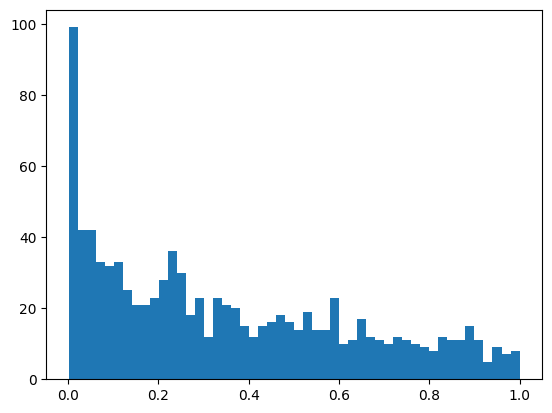

In [39]:
import pylab 
pylab.hist([i.item() for i in rank], bins=50)

In [ ]:
np.mean(rank) 

0.14848925961341441

In [42]:
{"mean_rank": np.mean(rank),
"recall@0.1%": sum(1 for i in rank if i <= 0.001)/len(rank),
"recall@0.2%": sum(1 for i in rank if i <= 0.002)/len(rank),
"recall@0.5%": sum(1 for i in rank if i <= 0.005)/len(rank),
"recall@1%": sum(1 for i in rank if i <= 0.01)/len(rank),
"recall@5%": sum(1 for i in rank if i <= 0.05)/len(rank),
"recall@10%": sum(1 for i in rank if i <= 0.1)/len(rank)}

{'mean_rank': 0.3508682808551329,
 'recall@0.1%': 0.0,
 'recall@0.2%': 0.011363636363636364,
 'recall@0.5%': 0.03202479338842975,
 'recall@1%': 0.056818181818181816,
 'recall@5%': 0.16942148760330578,
 'recall@10%': 0.25413223140495866}

array([0.00103306])

In [112]:
1 - query[0] @ db[0].T

0.8580149806785626

In [41]:
db.shape

(966, 512)

In [ ]:
from deepface import DeepFace
import wandb
import os
wandb.init(project="minusface")
import cv2
import numpy as np
from insightface.app import FaceAnalysis

app = FaceAnalysis(name="buffalo_l")
app.prepare(ctx_id=0, det_size=(128, 128))

def get_embedding(path, det_thresh):
    img = cv2.imread(path)
    if img is None:
        return None
    img = cv2.resize(img, (128,128))
    app.det_model.det_thresh = det_thresh #higher (0.01->0.1) will decrease some very low dis, making it work
    faces = app.get(img, max_num=5)
    max_area = 0
    max_area_idx = 0
    for idx, face in enumerate(faces):
        box = face.bbox
        area = (box[2] - box[0]) * (box[3] - box[1])
        if area > max_area:
            max_area = area
            max_area_idx = idx
    if len(faces) == 0:
        return None
    return faces[max_area_idx].normed_embedding


# all_db_embeddings = []
# all_residue_embeddings = [] 

# import tqdm

# for test_id in tqdm.tqdm(range(1, len(os.listdir("/path/to/FaceLinkGen/original_pair_face/"))-1)):
#     embedding = get_embedding(f"/path/to/FaceLinkGen/original_pair_face/{test_id:04d}.png", det_thresh=0.5)
#     all_db_embeddings.append(embedding)
#     residue_embedding = get_embedding(f"./results/{test_id:04d}.png", det_thresh=0.1)
#     all_residue_embeddings.append(residue_embedding)

# import pickle
# with open("results/embeddings.pkl", "wb") as f:
#     pickle.dump({
#         "db": all_db_embeddings,
#         "residue": all_residue_embeddings
#     }, f)

In [84]:
# original = get_embedding("/path/to/FaceLinkGen/original_pair_face/001.png", det_thresh=0.5)
# residue = get_embedding("./results/001.png", det_thresh=0.1)
# original @ residue.T 

-0.04852101